<a href="https://colab.research.google.com/github/madhankumar003/HTIC_Practice_codes/blob/main/Cnn_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from torch.utils.data import random_split

transform = transforms.ToTensor()
#image to tensors
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)





train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))




train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 447kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]

Training samples: 54000
Validation samples: 6000
Test samples: 10000


In [2]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc1 = nn.Linear(
            7 * 7 * 64,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.fc2(x)

        return x

In [3]:
model = CNN()
cross_loss = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Forward propagation
        outputs = model(images)

        # Calculate loss
        loss = cross_loss(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)


    model.eval()

    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            # Forward propagation only
            outputs = model(images)

            # Validation loss
            loss = cross_loss(outputs, labels)

            total_val_loss += loss.item()

            # Validation prediction
            predictions = outputs.argmax(dim=1)

            correct_val += (
                (predictions == labels).sum().item()
            )

            total_val += labels.size(0)

    # Calculate epoch-level validation values

    val_loss = total_val_loss / len(val_loader)

    val_accuracy = (
        100 * correct_val / total_val
    )

    train_loss = total_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    train_acc_history.append(train_accuracy)
    val_acc_history.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch 1/10 | Train Loss: 0.1872 | Train Acc: 94.32% | Val Loss: 0.0803 | Val Acc: 97.55%
Epoch 2/10 | Train Loss: 0.0526 | Train Acc: 98.36% | Val Loss: 0.0595 | Val Acc: 98.20%
Epoch 3/10 | Train Loss: 0.0359 | Train Acc: 98.90% | Val Loss: 0.0480 | Val Acc: 98.50%
Epoch 4/10 | Train Loss: 0.0263 | Train Acc: 99.17% | Val Loss: 0.0526 | Val Acc: 98.48%
Epoch 5/10 | Train Loss: 0.0201 | Train Acc: 99.38% | Val Loss: 0.0445 | Val Acc: 98.55%
Epoch 6/10 | Train Loss: 0.0163 | Train Acc: 99.48% | Val Loss: 0.0366 | Val Acc: 99.03%
Epoch 7/10 | Train Loss: 0.0129 | Train Acc: 99.57% | Val Loss: 0.0485 | Val Acc: 98.40%
Epoch 8/10 | Train Loss: 0.0108 | Train Acc: 99.63% | Val Loss: 0.0374 | Val Acc: 98.87%
Epoch 9/10 | Train Loss: 0.0080 | Train Acc: 99.75% | Val Loss: 0.0489 | Val Acc: 98.65%
Epoch 10/10 | Train Loss: 0.0065 | Train Acc: 99.79% | Val Loss: 0.0380 | Val Acc: 98.87%


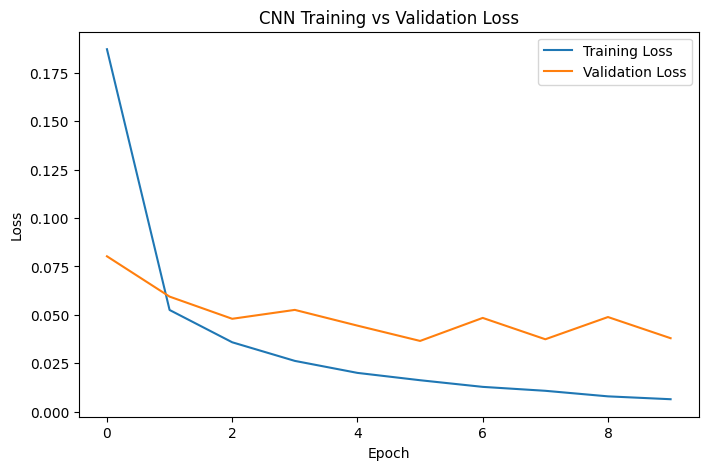

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_loss_history,
    label="Training Loss"
)

plt.plot(
    val_loss_history,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")

plt.legend()
plt.show()

**inference**

In [20]:
import torch
from torchvision import transforms
from PIL import Image, ImageOps

def test_real_image(image_path, trained_model):

    transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor()
    ])


    img = Image.open(image_path).convert('L')


    #img = ImageOps.invert(img)

    # 3. Apply the resize and tensor transformations (Shape becomes [1, 28, 28])
    img_tensor = transform(img)

    img_batch = img_tensor.unsqueeze(0)

    # 5. Lock the model (Evaluation Mode)
    trained_model.eval()


    with torch.no_grad():
        raw_outputs = trained_model(img_batch)

        # 7. Extract the highest probability index
        final_prediction = raw_outputs.argmax(dim=1).item()

    print(f"The CNN predicts this digit is: {final_prediction}")
    return final_prediction


test_real_image("4.jpg", model)

The CNN predicts this digit is: 4


4